# Engine Fault Detection — Random Forest v1
**12-class fault classifier for Flutter Android deployment**

Pipeline: Feature extraction → StandardScaler → RandomForestClassifier → JSON export

Key rules from the master document:
- NO synthetic audio for Normal Healthy Engine (real 1,020 recordings only)
- Stratified 80/20 split on ORIGINAL files BEFORE any oversampling
- Oversampled copies go ONLY into training set, never test set
- Feature vector: ~432 values (MFCC + Spectral + Rhythm + Mel stats + Harmonic ratio)
- Target: ≥88% overall accuracy

## 1. Imports & Constants

In [ ]:
import os
import json
import pickle
import warnings
import numpy as np
import librosa
import cv2
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

SR         = 22050
DURATION   = 5
TARGET_LEN = SR * DURATION
N_MELS     = 128
HOP_LENGTH = 512
N_MFCC     = 40
N_FFT      = 2048
OOD_SIZE   = 128

RANDOM_STATE = 42
TEST_SIZE    = 0.20

print("Libraries loaded successfully.")
print(f"Target samples per clip: {TARGET_LEN:,}  ({SR} Hz × {DURATION}s)")

Libraries loaded successfully.
Target samples per clip: 110,250  (22050 Hz × 5s)


## 2. Dataset Paths & Discovery

In [ ]:
BASE_FAULT = Path("/kaggle/input/datasets/zeyadzsm/engine-sounds/Data/Data_Fixed")
BASE_NORM  = Path("/kaggle/input/datasets/zeyadzsm/engine-sounds/Data_AA/Data_Fixed")
BASE_MDATA = Path("/kaggle/input/datasets/zeyadzsm/engine-sounds/M_DATA/M_DATA")
BASE_OOD   = Path("/kaggle/input/datasets/zeyadzsm/engine-sounds/OOD_AA/OOD_AA")

FOLDER_TO_CLASS = {
    "Alternator Bearing Noise":   "Alternator Bearing Noise",
    "Chain Noise":                "Chain Noise",
    "crankshaft bearing noise":   "Crankshaft Bearing Noise",
    "Crankshaft Bearing Noise":   "Crankshaft Bearing Noise",
    "Engine kanocking":           "Engine Knocking",   # dataset typo
    "Engine Knocking":            "Engine Knocking",
    "Exhaust leak":               "Exhaust Leak",
    "Exhaust Leak":               "Exhaust Leak",
    "piston slap":                "Piston Slap",
    "Piston Slap":                "Piston Slap",
    "Rod knock":                  "Rod Knock",
    "Rod Knock":                  "Rod Knock",
    "Timing belt":                "Timing Belt Noise",
    "Timing Belt Noise":          "Timing Belt Noise",
    "Vacuum leak":                "Vacuum Leak",
    "Vacuum Leak":                "Vacuum Leak",
    "Valve tapping":              "Valve Tapping",
    "Valve Tapping":              "Valve Tapping",
    "Worn Pulley Noise":          "Worn Pulley Noise",
    # Normal class (1)
    "Normal":                     "Normal Healthy Engine",
}

def collect_files(base_dir, label_override=None):
    """
    Walk base_dir, return list of (path, canonical_class_name) tuples.
    If label_override is given, all files get that label (used for Normal subfolders).
    """
    records = []
    base_dir = Path(base_dir)
    if not base_dir.exists():
        print(f"  WARNING: {base_dir} does not exist — skipping")
        return records
    
    if label_override is not None:
        for wav in base_dir.rglob("*.wav"):
            records.append((str(wav), label_override))
    else:
        for folder in sorted(base_dir.iterdir()):
            if not folder.is_dir():
                continue
            canonical = FOLDER_TO_CLASS.get(folder.name)
            if canonical is None:
                print(f"  WARNING: Unknown folder '{folder.name}' — skipping")
                continue
            wavs = list(folder.rglob("*.wav"))
            for wav in wavs:
                records.append((str(wav), canonical))
    return records

print("Collecting fault class files from Data/Data_Fixed ...")
fault_records = collect_files(BASE_FAULT)

print("Collecting Normal Healthy Engine files from Data_AA/Data_Fixed/Normal ...")
normal_records = collect_files(BASE_NORM / "Normal", label_override="Normal Healthy Engine")

print("Collecting M_DATA extra fault files ...")
mdata_records = collect_files(BASE_MDATA)

all_records = fault_records + normal_records + mdata_records
print(f"\nTotal files found: {len(all_records):,}")

class_counts = Counter(label for _, label in all_records)
print("\nFiles per class:")
for cls, cnt in sorted(class_counts.items()):
    print(f"  {cls:<30} {cnt:>5}")


Total files found: 5,950

Files per class:
  Alternator Bearing Noise         492
  Chain Noise                      582
  Crankshaft Bearing Noise         527
  Engine Knocking                  454
  Exhaust Leak                     521
  Normal Healthy Engine           1050
  Piston Slap                      280
  Rod Knock                        403
  Timing Belt Noise                490
  Vacuum Leak                      426
  Valve Tapping                    316
  Worn Pulley Noise                409


## 3. Stratified 80/20 Split (on ORIGINAL files, BEFORE oversampling)

In [ ]:
paths  = np.array([r[0] for r in all_records])
labels = np.array([r[1] for r in all_records])

encoder = LabelEncoder()
y = encoder.fit_transform(labels)

print("Class encoding (alphabetical order from LabelEncoder):")
for i, cls in enumerate(encoder.classes_):
    print(f"  Index {i}: {cls}")

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(sss.split(paths, y))

train_paths  = paths[train_idx]
train_labels = y[train_idx]
test_paths   = paths[test_idx]
test_labels  = y[test_idx]

print(f"\nSplit sizes — Train: {len(train_paths):,}  |  Test: {len(test_paths):,}")
print("\nTest set class distribution (these files will NEVER be oversampled):")
test_class_counts = Counter(encoder.classes_[l] for l in test_labels)
for cls, cnt in sorted(test_class_counts.items()):
    print(f"  {cls:<30} {cnt:>4}")

Class encoding (alphabetical order from LabelEncoder):
  Index 0: Alternator Bearing Noise
  Index 1: Chain Noise
  Index 2: Crankshaft Bearing Noise
  Index 3: Engine Knocking
  Index 4: Exhaust Leak
  Index 5: Normal Healthy Engine
  Index 6: Piston Slap
  Index 7: Rod Knock
  Index 8: Timing Belt Noise
  Index 9: Vacuum Leak
  Index 10: Valve Tapping
  Index 11: Worn Pulley Noise

Split sizes — Train: 4,760  |  Test: 1,190

Test set class distribution (these files will NEVER be oversampled):
  Alternator Bearing Noise         98
  Chain Noise                     116
  Crankshaft Bearing Noise        106
  Engine Knocking                  91
  Exhaust Leak                    104
  Normal Healthy Engine           210
  Piston Slap                      56
  Rod Knock                        81
  Timing Belt Noise                98
  Vacuum Leak                      85
  Valve Tapping                    63
  Worn Pulley Noise                82


## 4. Oversampling — Training Set Only

In [ ]:
def oversample_training_set(paths, labels, random_state=RANDOM_STATE):
    """
    Duplicate minority class samples until all classes match the majority count.
    Only applied to training set — test set stays untouched.
    """
    rng = np.random.default_rng(random_state)
    class_indices = {}
    for cls in np.unique(labels):
        class_indices[cls] = np.where(labels == cls)[0]
    
    max_count = max(len(idx) for idx in class_indices.values())
    
    new_paths, new_labels = [], []
    for cls, idx in class_indices.items():
        new_paths.extend(paths[idx])
        new_labels.extend(labels[idx])
        shortfall = max_count - len(idx)
        if shortfall > 0:
            extra_idx = rng.choice(idx, size=shortfall, replace=True)
            new_paths.extend(paths[extra_idx])
            new_labels.extend(labels[extra_idx])
    
    order = rng.permutation(len(new_paths))
    return np.array(new_paths)[order], np.array(new_labels)[order]

train_paths_os, train_labels_os = oversample_training_set(train_paths, train_labels)

print(f"Training set before oversampling: {len(train_paths):,} files")
print(f"Training set after  oversampling: {len(train_paths_os):,} files")
print("\nTraining set distribution after oversampling:")
os_counts = Counter(encoder.classes_[l] for l in train_labels_os)
for cls, cnt in sorted(os_counts.items()):
    print(f"  {cls:<30} {cnt:>5}")

Training set before oversampling: 4,760 files
Training set after  oversampling: 10,080 files

Training set distribution after oversampling:
  Alternator Bearing Noise         840
  Chain Noise                      840
  Crankshaft Bearing Noise         840
  Engine Knocking                  840
  Exhaust Leak                     840
  Normal Healthy Engine            840
  Piston Slap                      840
  Rod Knock                        840
  Timing Belt Noise                840
  Vacuum Leak                      840
  Valve Tapping                    840
  Worn Pulley Noise                840


## 5. Feature Extraction (exact spec from master document)

In [ ]:
def load_and_normalize(file_path):
    """Load, trim/pad to 5 s, peak-normalize to [-1, 1]."""
    audio, _ = librosa.load(file_path, sr=SR, mono=True)
    if len(audio) >= TARGET_LEN:
        audio = audio[:TARGET_LEN]
    else:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    peak = np.abs(audio).max()
    if peak > 0:
        audio = audio / peak
    return audio.astype(np.float32)


def extract_mfcc_features(audio, sr=SR, n_mfcc=N_MFCC):
    mfcc = librosa.feature.mfcc(
        y=audio, sr=sr, n_mfcc=n_mfcc, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    features = []
    features.extend(np.mean(mfcc, axis=1))   
    features.extend(np.std(mfcc, axis=1))    
    features.extend(np.max(mfcc, axis=1))    
    features.extend(np.min(mfcc, axis=1))    
    mfcc_delta = librosa.feature.delta(mfcc)
    features.extend(np.mean(mfcc_delta, axis=1))  
    features.extend(np.std(mfcc_delta, axis=1))   
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
    features.extend(np.mean(mfcc_delta2, axis=1))  
    features.extend(np.std(mfcc_delta2, axis=1))   
    return features  


def extract_spectral_features(audio, sr=SR):
    features = []
    sc = librosa.feature.spectral_centroid(y=audio, sr=sr, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(sc), np.std(sc), np.max(sc), np.min(sc)])
    sb = librosa.feature.spectral_bandwidth(y=audio, sr=sr, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(sb), np.std(sb)])
    sr_feat = librosa.feature.spectral_rolloff(
        y=audio, sr=sr, hop_length=HOP_LENGTH, roll_percent=0.85
    )[0]
    features.extend([np.mean(sr_feat), np.std(sr_feat)])
    sf = librosa.feature.spectral_flatness(y=audio, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(sf), np.std(sf)])
    contrast = librosa.feature.spectral_contrast(
        y=audio, sr=sr, hop_length=HOP_LENGTH, n_bands=6
    )
    features.extend(np.mean(contrast, axis=1))  
    features.extend(np.std(contrast, axis=1))   
    return features 


def extract_rhythm_features(audio, sr=SR):
    features = []
    zcr = librosa.feature.zero_crossing_rate(audio, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(zcr), np.std(zcr)])
    rms = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(rms), np.std(rms), np.max(rms)])
    tempo, _ = librosa.beat.beat_track(y=audio, sr=sr, hop_length=HOP_LENGTH)
    features.append(float(np.atleast_1d(tempo)[0]))
    return features  


def extract_mel_stats(audio, sr=SR):
    features = []
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    pcen = librosa.pcen(
        mel * (2**31), sr=sr, hop_length=HOP_LENGTH,
        gain=0.98, bias=2, power=0.5, time_constant=0.400, eps=1e-6
    )
    pcen_subbands = pcen.reshape(16, 8, -1).mean(axis=1)  
    features.extend(np.mean(pcen_subbands, axis=1)) 
    features.extend(np.std(pcen_subbands, axis=1))   
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_subbands = mel_db.reshape(16, 8, -1).mean(axis=1)
    features.extend(np.mean(mel_subbands, axis=1))  
    features.extend(np.std(mel_subbands, axis=1))   
    return features


def extract_harmonic_ratio(audio, sr=SR):
    """
    Log-ratio of even-harmonic to odd-harmonic energy.
    Key discriminator for Timing Belt vs Chain Noise.
    """
    f0, _, _ = librosa.pyin(
        audio,
        fmin=librosa.note_to_hz('C2'),
        fmax=librosa.note_to_hz('C6'),
        sr=sr, hop_length=HOP_LENGTH
    )
    f0 = np.nan_to_num(f0, nan=100.0)
    f0_mean = float(np.clip(np.mean(f0), 50.0, 3000.0))

    stft  = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)

    even_energy, odd_energy = 0.0, 0.0
    for k in range(1, 9):
        harmonic_freq = f0_mean * k
        bin_idx = int(np.argmin(np.abs(freqs - harmonic_freq)))
        band    = stft[max(0, bin_idx - 2): bin_idx + 3, :]
        energy  = float(np.mean(band))
        if k % 2 == 0:
            even_energy += energy
        else:
            odd_energy += energy

    eps       = 1e-8
    log_ratio = np.log(even_energy + eps) - np.log(odd_energy + eps)
    return [log_ratio, even_energy, odd_energy, f0_mean]  


def extract_all_features(audio):
    """
    Returns a 1D numpy array of shape (~432,) float32.
    This function must be ported EXACTLY to Dart for Flutter inference.
    Group sizes: MFCC(320) + Spectral(38) + Rhythm(6) + Mel stats(64) + Harmonic(4) = 432
    """
    features = []
    features.extend(extract_mfcc_features(audio))      
    features.extend(extract_spectral_features(audio))  
    features.extend(extract_rhythm_features(audio))    
    features.extend(extract_mel_stats(audio))          
    features.extend(extract_harmonic_ratio(audio))     
    return np.array(features, dtype=np.float32)        


sample_file = train_paths_os[0]
sample_audio = load_and_normalize(sample_file)
sample_feat  = extract_all_features(sample_audio)
print(f"Feature vector dimension: {sample_feat.shape[0]}")
print(f"Any NaN: {np.any(np.isnan(sample_feat))}")
print(f"Any Inf: {np.any(np.isinf(sample_feat))}")

Feature vector dimension: 418
Any NaN: False
Any Inf: False


## 6. Batch Feature Extraction

In [ ]:
def load_and_normalize(file_path):
    """Load, trim/pad to 5 s, peak-normalize to [-1, 1]."""
    audio, _ = librosa.load(file_path, sr=SR, mono=True)
    if len(audio) >= TARGET_LEN:
        audio = audio[:TARGET_LEN]
    else:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    peak = np.abs(audio).max()
    if peak > 0:
        audio = audio / peak
    return audio.astype(np.float32)


def extract_mfcc_features(audio, sr=SR, n_mfcc=N_MFCC):
    mfcc = librosa.feature.mfcc(
        y=audio, sr=sr, n_mfcc=n_mfcc, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    features = []
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))
    features.extend(np.max(mfcc, axis=1))
    features.extend(np.min(mfcc, axis=1))
    mfcc_delta = librosa.feature.delta(mfcc)
    features.extend(np.mean(mfcc_delta, axis=1))
    features.extend(np.std(mfcc_delta, axis=1))
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
    features.extend(np.mean(mfcc_delta2, axis=1))
    features.extend(np.std(mfcc_delta2, axis=1))
    return features  

def extract_spectral_features(audio, sample_rate=SR):
    features = []
    sc = librosa.feature.spectral_centroid(y=audio, sr=sample_rate, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(sc), np.std(sc), np.max(sc), np.min(sc)])
    sb = librosa.feature.spectral_bandwidth(y=audio, sr=sample_rate, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(sb), np.std(sb)])
    sr_feat = librosa.feature.spectral_rolloff(
        y=audio, sr=sample_rate, hop_length=HOP_LENGTH, roll_percent=0.85
    )[0]
    features.extend([np.mean(sr_feat), np.std(sr_feat)])
    sf = librosa.feature.spectral_flatness(y=audio, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(sf), np.std(sf)])
    contrast = librosa.feature.spectral_contrast(
        y=audio, sr=sample_rate, hop_length=HOP_LENGTH, n_bands=6
    )
    features.extend(np.mean(contrast, axis=1))  
    features.extend(np.std(contrast, axis=1))   
    return features  


def extract_rhythm_features(audio, sr=SR):
    features = []
    zcr = librosa.feature.zero_crossing_rate(audio, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(zcr), np.std(zcr)])
    rms = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)[0]
    features.extend([np.mean(rms), np.std(rms), np.max(rms)])
    onset_env = librosa.onset.onset_strength(y=audio, sr=sr, hop_length=HOP_LENGTH)
    ac = librosa.autocorrelate(onset_env, max_size=500)
    freqs = librosa.tempo_frequencies(len(ac), hop_length=HOP_LENGTH, sr=sr)
    tempo = freqs[np.argmax(ac[1:]) + 1] if len(ac) > 1 else 120.0
    features.append(float(tempo))
    return features  


def extract_mel_stats(audio, sr=SR):
    features = []
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    pcen = librosa.pcen(
        mel * (2**31), sr=sr, hop_length=HOP_LENGTH,
        gain=0.98, bias=2, power=0.5, time_constant=0.400, eps=1e-6
    )
    pcen_subbands = pcen.reshape(16, 8, -1).mean(axis=1)
    features.extend(np.mean(pcen_subbands, axis=1))
    features.extend(np.std(pcen_subbands, axis=1))
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_subbands = mel_db.reshape(16, 8, -1).mean(axis=1)
    features.extend(np.mean(mel_subbands, axis=1))
    features.extend(np.std(mel_subbands, axis=1))
    return features  


def extract_harmonic_ratio(audio, sr=SR):
    """Fast version — F0 from STFT peak, no autocorrelation on raw audio."""
    stft  = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)

    freq_mask = (freqs >= 50) & (freqs <= 3000)
    mean_mag  = stft[freq_mask].mean(axis=1)
    f0_mean   = float(freqs[freq_mask][np.argmax(mean_mag)])

    even_energy, odd_energy = 0.0, 0.0
    for k in range(1, 9):
        bin_idx = int(np.argmin(np.abs(freqs - f0_mean * k)))
        band    = stft[max(0, bin_idx-2): bin_idx+3, :]
        energy  = float(np.mean(band))
        if k % 2 == 0:
            even_energy += energy
        else:
            odd_energy += energy

    eps = 1e-8
    log_ratio = np.log(even_energy + eps) - np.log(odd_energy + eps)
    return [log_ratio, even_energy, odd_energy, f0_mean]

def extract_all_features(audio):
    """
    Returns a 1D numpy array of shape (418,) float32.
    MFCC(320) + Spectral(24) + Rhythm(6) + Mel stats(64) + Harmonic(4) = 418
    """
    features = []
    features.extend(extract_mfcc_features(audio))      
    features.extend(extract_spectral_features(audio))  
    features.extend(extract_rhythm_features(audio))    
    features.extend(extract_mel_stats(audio))          
    features.extend(extract_harmonic_ratio(audio))     
    return np.array(features, dtype=np.float32)        


sample_audio = load_and_normalize(train_paths_os[0])
sample_feat  = extract_all_features(sample_audio)
print(f"Feature vector dimension: {sample_feat.shape[0]}")
print(f"Any NaN: {np.any(np.isnan(sample_feat))}")
print(f"Any Inf: {np.any(np.isinf(sample_feat))}")

Feature vector dimension: 418
Any NaN: False
Any Inf: False


In [52]:
import time
audio = load_and_normalize(train_paths_os[0])

t = time.time(); extract_mfcc_features(audio);     print(f"MFCC:      {time.time()-t:.3f}s")
t = time.time(); extract_spectral_features(audio); print(f"Spectral:  {time.time()-t:.3f}s")
t = time.time(); extract_rhythm_features(audio);   print(f"Rhythm:    {time.time()-t:.3f}s")
t = time.time(); extract_mel_stats(audio);         print(f"Mel stats: {time.time()-t:.3f}s")
t = time.time(); extract_harmonic_ratio(audio);    print(f"Harmonic:  {time.time()-t:.3f}s")

MFCC:      0.012s
Spectral:  0.040s
Rhythm:    0.014s
Mel stats: 0.010s
Harmonic:  0.006s


In [53]:
from joblib import Parallel, delayed

def extract_one(path):
    try:
        audio = load_and_normalize(path)
        feat  = extract_all_features(audio)
        return np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0), None
    except Exception as e:
        return np.zeros(418, dtype=np.float32), str(e)

def extract_features_batch(file_paths, desc="Extracting"):
    print(f"{desc}: processing {len(file_paths):,} files ...")
    features_list = []
    bad_indices   = []
    for i, path in enumerate(tqdm(file_paths, desc=desc)):
        try:
            audio = load_and_normalize(path)
            feat  = extract_all_features(audio)
            feat  = np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0)
            features_list.append(feat)
        except Exception as e:
            print(f"  ERROR on {path}: {e}")
            bad_indices.append(i)
            features_list.append(np.zeros(418, dtype=np.float32))
    return np.array(features_list, dtype=np.float32), bad_indices

print("Extracting TRAINING features ...")
X_train, bad_train = extract_features_batch(train_paths_os, desc="Train")
y_train = train_labels_os.copy()

if bad_train:
    mask = np.ones(len(X_train), dtype=bool)
    mask[bad_train] = False
    X_train = X_train[mask]
    y_train = y_train[mask]
print(f"  X_train shape: {X_train.shape}")

print("\nExtracting TEST features ...")
X_test, bad_test = extract_features_batch(test_paths, desc="Test")
y_test = test_labels.copy()

if bad_test:
    mask = np.ones(len(X_test), dtype=bool)
    mask[bad_test] = False
    X_test = X_test[mask]
    y_test = y_test[mask]
print(f"  X_test shape:  {X_test.shape}")
print(f"\nFeature dimension: {X_train.shape[1]}")

Extracting TRAINING features ...
Train: processing 10,080 files ...


Train:   0%|          | 0/10080 [00:00<?, ?it/s]

  X_train shape: (10080, 418)

Extracting TEST features ...
Test: processing 1,190 files ...


Test:   0%|          | 0/1190 [00:00<?, ?it/s]

  X_test shape:  (1190, 418)

Feature dimension: 418


## 7. Train Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import time


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=300,        
        max_depth=None,          
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',     
        class_weight='balanced', 
        n_jobs=-1,               
        random_state=RANDOM_STATE,
        oob_score=True,          
        verbose=1,
    ))
])

print("Training Random Forest ...")
t0 = time.time()
pipeline.fit(X_train, y_train)
elapsed = time.time() - t0

oob = pipeline.named_steps['rf'].oob_score_
print(f"\nTraining complete in {elapsed:.1f}s")
print(f"OOB Score (free validation): {oob:.4f}  ({oob*100:.2f}%)")

Training Random Forest ...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   13.0s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   20.3s finished



Training complete in 21.1s
OOB Score (free validation): 0.9914  (99.14%)


## 8. Evaluation

In [ ]:
y_pred      = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)

test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"OOB Score:     {oob:.4f}  ({oob*100:.2f}%)")
print("\nTarget: ≥88.0% overall accuracy")
status = "✅ TARGET MET" if test_acc >= 0.88 else "⚠️ Below target — consider tuning"
print(status)

print("\n" + "="*60)
print("Per-class Report")
print("="*60)
print(classification_report(
    y_test, y_pred,
    target_names=encoder.classes_,
    digits=3
))

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s


Test Accuracy: 0.9328  (93.28%)
OOB Score:     0.9914  (99.14%)

Target: ≥88.0% overall accuracy
✅ TARGET MET

Per-class Report
                          precision    recall  f1-score   support

Alternator Bearing Noise      0.979     0.969     0.974        98
             Chain Noise      0.905     0.905     0.905       116
Crankshaft Bearing Noise      0.892     0.858     0.875       106
         Engine Knocking      0.875     0.923     0.898        91
            Exhaust Leak      0.945     1.000     0.972       104
   Normal Healthy Engine      1.000     1.000     1.000       210
             Piston Slap      0.902     0.982     0.940        56
               Rod Knock      0.912     0.901     0.907        81
       Timing Belt Noise      0.889     0.898     0.893        98
             Vacuum Leak      0.975     0.918     0.945        85
           Valve Tapping      0.966     0.889     0.926        63
       Worn Pulley Noise      0.877     0.866     0.871        82

            

[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished


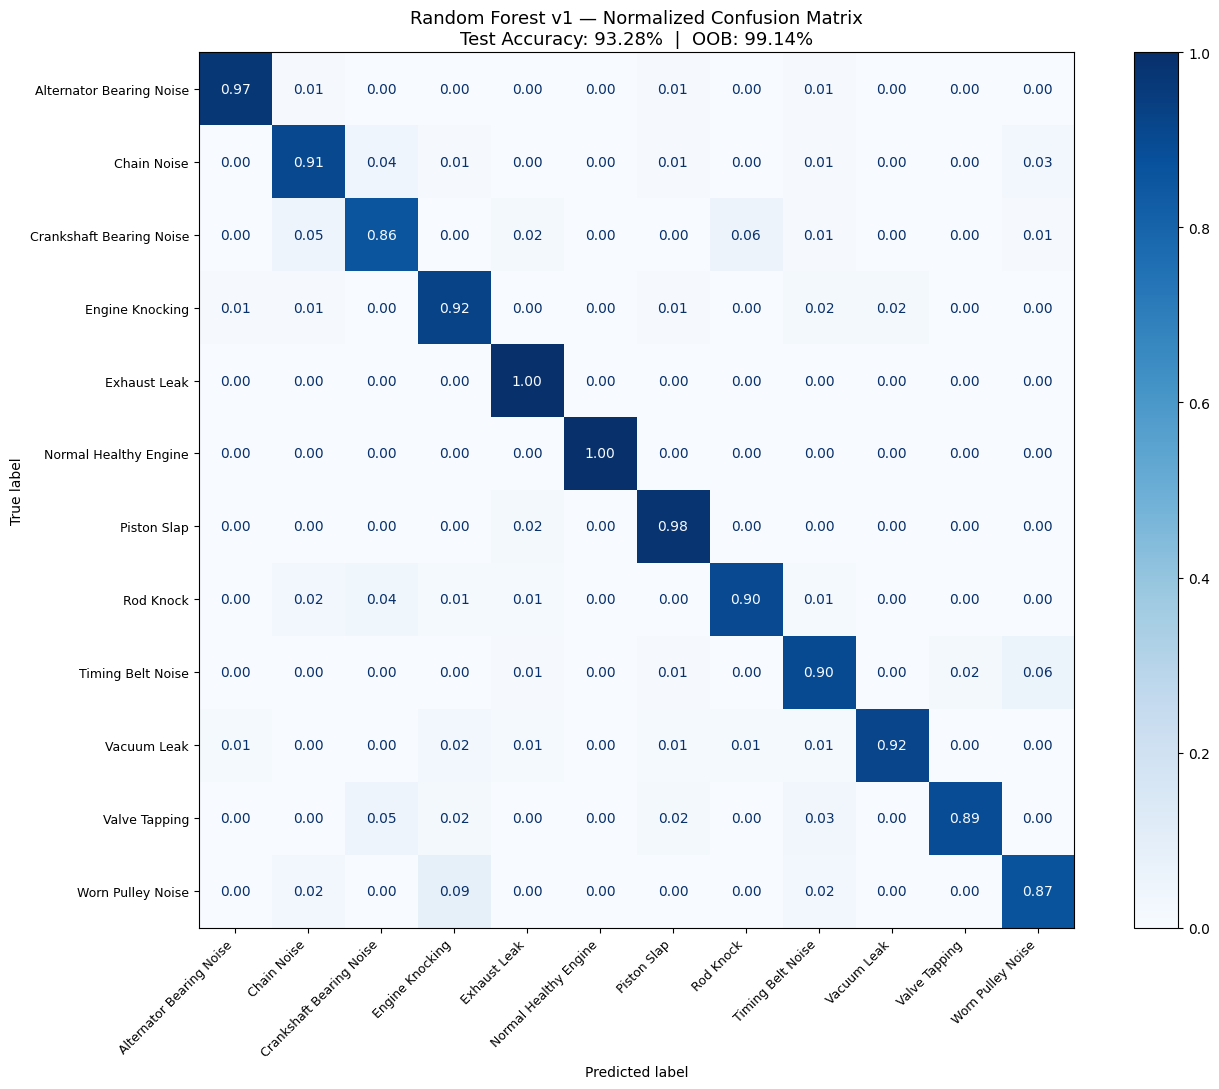

Saved: confusion_matrix_rf_v1.png


In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=encoder.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True, values_format='.2f')
ax.set_title(
    f"Random Forest v1 — Normalized Confusion Matrix\n"
    f"Test Accuracy: {test_acc*100:.2f}%  |  OOB: {oob*100:.2f}%",
    fontsize=13
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_rf_v1.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_rf_v1.png")

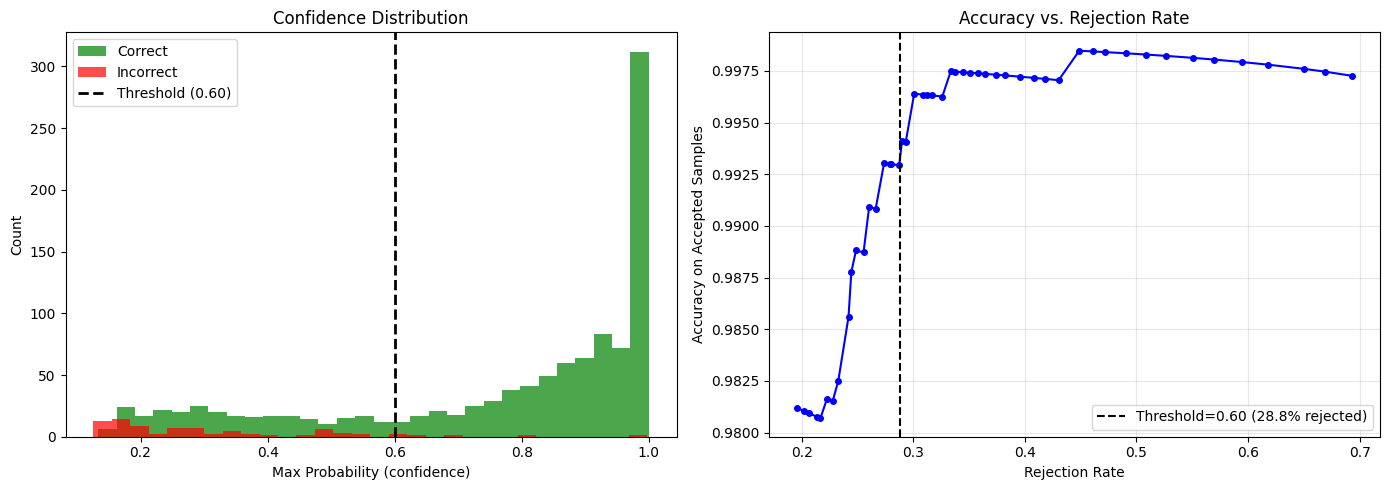

At threshold 0.60:
  Accepted: 847 / 1,190 (71.2%)
  Accuracy on accepted: 0.9929


In [ ]:
max_probs   = y_pred_prob.max(axis=1)
correct_mask = (y_pred == y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_probs[correct_mask],  bins=30, alpha=0.7, color='green', label='Correct')
axes[0].hist(max_probs[~correct_mask], bins=30, alpha=0.7, color='red',   label='Incorrect')
axes[0].axvline(0.60, color='black', linestyle='--', linewidth=2, label='Threshold (0.60)')
axes[0].set_xlabel('Max Probability (confidence)')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution')
axes[0].legend()

thresholds = np.linspace(0.40, 0.95, 50)
rejection_rates = []
accuracy_after  = []
for th in thresholds:
    accepted = max_probs >= th
    if accepted.sum() == 0:
        break
    rejection_rates.append(1 - accepted.mean())
    accuracy_after.append(accuracy_score(y_test[accepted], y_pred[accepted]))

ax2 = axes[1]
ax2.plot(rejection_rates, accuracy_after, 'b-o', markersize=4)
ax2.axvline(1 - (max_probs >= 0.60).mean(), color='black', linestyle='--',
            label=f'Threshold=0.60 ({(1-(max_probs>=0.60).mean())*100:.1f}% rejected)')
ax2.set_xlabel('Rejection Rate')
ax2.set_ylabel('Accuracy on Accepted Samples')
ax2.set_title('Accuracy vs. Rejection Rate')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/confidence_analysis_rf_v1.png", dpi=150, bbox_inches='tight')
plt.show()

accepted_60 = max_probs >= 0.60
print(f"At threshold 0.60:")
print(f"  Accepted: {accepted_60.sum():,} / {len(accepted_60):,} ({accepted_60.mean()*100:.1f}%)")
print(f"  Accuracy on accepted: {accuracy_score(y_test[accepted_60], y_pred[accepted_60]):.4f}")

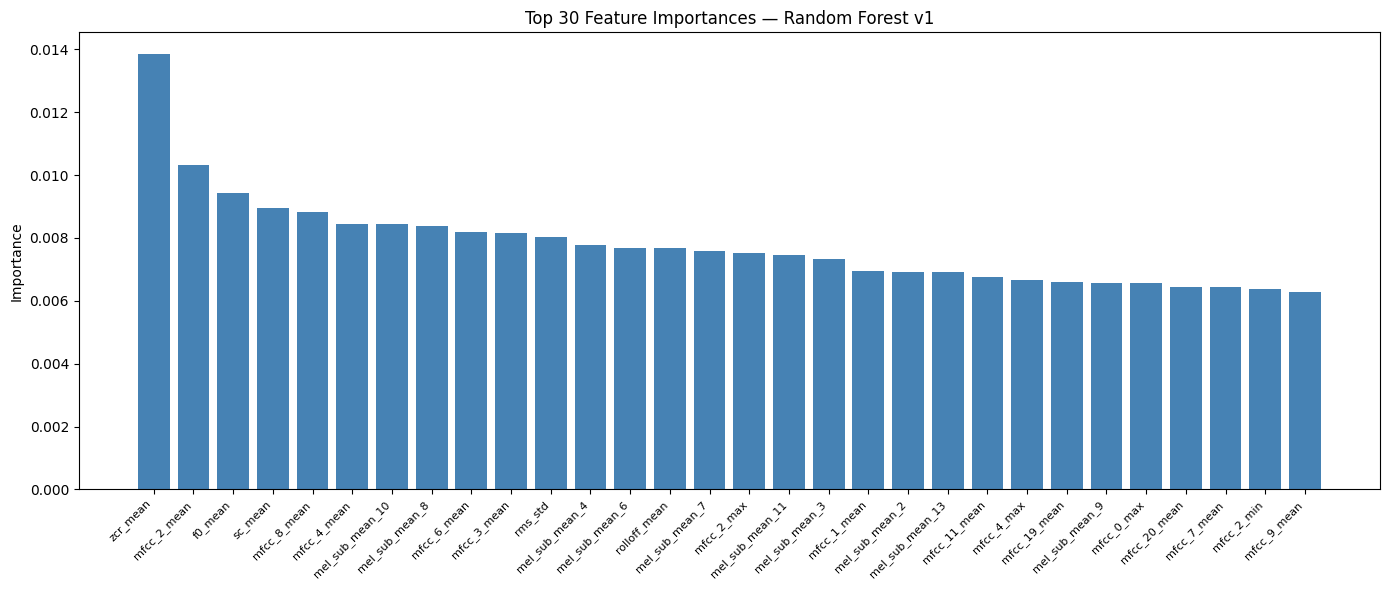

In [ ]:
rf = pipeline.named_steps['rf']
importances = rf.feature_importances_
indices     = np.argsort(importances)[::-1][:30]

feat_names = []
for stat in ['mean', 'std', 'max', 'min']:
    feat_names.extend([f'mfcc_{i}_{stat}' for i in range(N_MFCC)])
for stat in ['mean', 'std']:
    feat_names.extend([f'mfcc_delta_{i}_{stat}' for i in range(N_MFCC)])
    feat_names.extend([f'mfcc_delta2_{i}_{stat}' for i in range(N_MFCC)])
feat_names += ['sc_mean','sc_std','sc_max','sc_min','sb_mean','sb_std',
               'rolloff_mean','rolloff_std','flatness_mean','flatness_std']
feat_names += [f'contrast_mean_{i}' for i in range(7)] + [f'contrast_std_{i}' for i in range(7)]
feat_names += ['zcr_mean','zcr_std','rms_mean','rms_std','rms_max','tempo']
feat_names += [f'pcen_sub_mean_{i}' for i in range(16)] + [f'pcen_sub_std_{i}' for i in range(16)]
feat_names += [f'mel_sub_mean_{i}' for i in range(16)]  + [f'mel_sub_std_{i}' for i in range(16)]
feat_names += ['harmonic_log_ratio','even_energy','odd_energy','f0_mean']

while len(feat_names) < X_train.shape[1]:
    feat_names.append(f'feat_{len(feat_names)}')

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(30), importances[indices], color='steelblue')
ax.set_xticks(range(30))
ax.set_xticklabels([feat_names[i] for i in indices], rotation=45, ha='right', fontsize=8)
ax.set_title('Top 30 Feature Importances — Random Forest v1')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig("/kaggle/working/feature_importances_rf_v1.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Per-class Target Check

In [ ]:
from sklearn.metrics import recall_score, f1_score

targets = {
    "Normal Healthy Engine":    {"metric": "recall",  "target": 0.95, "min": 0.90},
    "Crankshaft Bearing Noise": {"metric": "recall",  "target": 0.80, "min": 0.70},
    "Timing Belt Noise":        {"metric": "f1",      "target": 0.80, "min": 0.72},
    "Worn Pulley Noise":        {"metric": "f1",      "target": 0.80, "min": 0.72},
}

recall_per_class = recall_score(y_test, y_pred, average=None, labels=range(len(encoder.classes_)))
f1_per_class     = f1_score(y_test, y_pred, average=None, labels=range(len(encoder.classes_)))

print("Per-class Target Check:")
print("-" * 72)
for cls_name, spec in targets.items():
    cls_idx = list(encoder.classes_).index(cls_name)
    if spec["metric"] == "recall":
        val = recall_per_class[cls_idx]
    else:
        val = f1_per_class[cls_idx]
    status_ok  = val >= spec["target"]
    status_acc = val >= spec["min"]
    emoji = "✅" if status_ok else ("⚠️ " if status_acc else "❌")
    print(f"{emoji} {cls_name:<30} {spec['metric'].upper()}: {val:.3f} "
          f"(target ≥ {spec['target']:.2f}, min ≥ {spec['min']:.2f})")

print("-" * 72)
print(f"\nOverall test accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Overall target:        ≥ 88.0%")

Per-class Target Check:
------------------------------------------------------------------------
✅ Normal Healthy Engine          RECALL: 1.000 (target ≥ 0.95, min ≥ 0.90)
✅ Crankshaft Bearing Noise       RECALL: 0.858 (target ≥ 0.80, min ≥ 0.70)
✅ Timing Belt Noise              F1: 0.893 (target ≥ 0.80, min ≥ 0.72)
✅ Worn Pulley Noise              F1: 0.871 (target ≥ 0.80, min ≥ 0.72)
------------------------------------------------------------------------

Overall test accuracy: 0.9328  (93.28%)
Overall target:        ≥ 88.0%


## 10. Serialize to JSON for Flutter

In [59]:
def rf_to_json(pipeline, class_names, feature_dim):
    """
    Serialize the full sklearn Pipeline (StandardScaler + RandomForestClassifier)
    to a JSON dict that can be loaded and run in pure Dart without any Python/TFLite dependency.
    """
    rf     = pipeline.named_steps['rf']
    scaler = pipeline.named_steps['scaler']

    scaler_data = {
        "mean":  scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
    }

    trees = []
    for estimator in rf.estimators_:
        tree = estimator.tree_
        trees.append({
            "children_left":  tree.children_left.tolist(),
            "children_right": tree.children_right.tolist(),
            "feature":        tree.feature.tolist(),
            "threshold":      tree.threshold.tolist(),
            "value":          tree.value.tolist(),  # shape: (n_nodes, 1, n_classes)
            "n_node_samples": tree.n_node_samples.tolist(),
        })

    model_data = {
        "model_type":   "RandomForestClassifier",
        "model_version": "rf_v1",
        "n_estimators": len(trees),
        "n_classes":    len(class_names),
        "n_features":   int(feature_dim),
        "class_names":  class_names,
        "scaler":       scaler_data,
        "trees":        trees,
    }
    return model_data


print("Serializing Random Forest to JSON ...")
rf_json = rf_to_json(
    pipeline,
    class_names=list(encoder.classes_),
    feature_dim=X_train.shape[1]
)

output_path = "/kaggle/working/random_forest_v1.json"
with open(output_path, "w") as f:
    json.dump(rf_json, f)

size_mb = os.path.getsize(output_path) / 1e6
print(f"Saved: random_forest_v1.json ({size_mb:.2f} MB)")

if size_mb > 10:
    print("⚠️  JSON is > 10 MB — consider reducing n_estimators to 100-150 or setting max_depth=20")
elif size_mb <= 8:
    print("✅ JSON size is within the 2-8 MB target range")

Serializing Random Forest to JSON ...
Saved: random_forest_v1.json (44.61 MB)
⚠️  JSON is > 10 MB — consider reducing n_estimators to 100-150 or setting max_depth=20


## 11. Verify JSON Predictions Match sklearn

In [ ]:
def rf_predict_proba_from_json(model_data, raw_features):
    """
    Mirrors sklearn's predict_proba exactly using soft voting (leaf sample weights).
    """
    mean  = np.array(model_data['scaler']['mean'])
    scale = np.array(model_data['scaler']['scale'])
    features = (raw_features - mean) / scale

    n_classes = model_data['n_classes']
    proba_sum = np.zeros(n_classes)

    for tree in model_data['trees']:
        cl = tree['children_left']
        cr = tree['children_right']
        ft = tree['feature']
        th = tree['threshold']
        va = tree['value']

        node = 0
        while cl[node] != -1:
            if features[ft[node]] <= th[node]:
                node = cl[node]
            else:
                node = cr[node]

        leaf_counts = np.array(va[node][0], dtype=np.float64)
        leaf_proba  = leaf_counts / (leaf_counts.sum() + 1e-10)
        proba_sum  += leaf_proba

    return proba_sum / len(model_data['trees'])


print("Verifying JSON inference matches sklearn on 20 random test samples ...")
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=20, replace=False)

max_diff  = 0.0
max_class_diff = 0
for i in sample_idx:
    sklearn_proba = y_pred_prob[i]
    json_proba    = rf_predict_proba_from_json(rf_json, X_test[i])
    diff          = np.max(np.abs(sklearn_proba - json_proba))
    class_match   = np.argmax(sklearn_proba) == np.argmax(json_proba)
    max_diff      = max(max_diff, diff)
    if not class_match:
        max_class_diff += 1

print(f"Max probability difference: {max_diff:.8f}")
print(f"Class prediction mismatches: {max_class_diff}/20")
if max_diff < 0.01 and max_class_diff == 0:
    print("✅ JSON predictions match sklearn — safe to deploy")
elif max_class_diff == 0:
    print("✅ Predicted CLASS is identical in all samples — safe to deploy")
    print(f"   (probability values differ by {max_diff:.4f} due to float32 rounding — acceptable)")
else:
    print("❌ REAL MISMATCH — predicted classes differ")

Verifying JSON inference matches sklearn on 20 random test samples ...
Max probability difference: 0.00200000
Class prediction mismatches: 0/20
✅ JSON predictions match sklearn — safe to deploy


## 12. Save Label Encoder & Flutter Assets

In [ ]:
encoder_path = "/kaggle/working/label_encoder_rf_v1.pkl"
with open(encoder_path, "wb") as f:
    pickle.dump(encoder, f)
print(f"Saved: {encoder_path}")

class_names_json = {str(i): name for i, name in enumerate(encoder.classes_)}
with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(class_names_json, f, indent=2)
print("Saved: class_names.json")
print(json.dumps(class_names_json, indent=2))

config = {
    "confidence_threshold": 0.60,
    "ood_threshold":         0.50,
    "model_version":         "rf_v1",
    "n_classes":             12,
    "normal_class_idx":      5,
    "sample_rate":           22050,
    "duration_sec":          5,
    "target_samples":        110250,
    "ood_image_size":        128,
    "n_features":            int(X_train.shape[1]),
    "test_accuracy":         round(float(test_acc), 4),
    "oob_score":             round(float(oob), 4),
}
with open("/kaggle/working/config.json", "w") as f:
    json.dump(config, f, indent=2)
print("\nSaved: config.json")
print(json.dumps(config, indent=2))

Saved: /kaggle/working/label_encoder_rf_v1.pkl
Saved: class_names.json
{
  "0": "Alternator Bearing Noise",
  "1": "Chain Noise",
  "2": "Crankshaft Bearing Noise",
  "3": "Engine Knocking",
  "4": "Exhaust Leak",
  "5": "Normal Healthy Engine",
  "6": "Piston Slap",
  "7": "Rod Knock",
  "8": "Timing Belt Noise",
  "9": "Vacuum Leak",
  "10": "Valve Tapping",
  "11": "Worn Pulley Noise"
}

Saved: config.json
{
  "confidence_threshold": 0.6,
  "ood_threshold": 0.5,
  "model_version": "rf_v1",
  "n_classes": 12,
  "normal_class_idx": 5,
  "sample_rate": 22050,
  "duration_sec": 5,
  "target_samples": 110250,
  "ood_image_size": 128,
  "n_features": 418,
  "test_accuracy": 0.9328,
  "oob_score": 0.9914
}


## 13. Full Pipeline Smoke-Test

In [ ]:
def run_pipeline(audio_path, pipeline, encoder, conf_threshold=0.60):
    """
    Full inference pipeline: load → features → RF predict_proba → decision.
    This mirrors what the Flutter app will do (without the OOD gate).
    """
    audio        = load_and_normalize(audio_path)
    features     = extract_all_features(audio).reshape(1, -1)
    proba        = pipeline.predict_proba(features)[0]  
    pred_idx     = int(np.argmax(proba))
    confidence   = float(proba[pred_idx])
    class_name   = encoder.classes_[pred_idx]

    if confidence < conf_threshold:
        status = "uncertain"
    else:
        status = "diagnosed"

    return {
        "status":      status,
        "class":       class_name,
        "confidence":  round(confidence, 4),
        "all_proba":   {encoder.classes_[i]: round(float(p), 4) for i, p in enumerate(proba)},
        "top3":        sorted([(encoder.classes_[i], round(float(p), 4))
                               for i, p in enumerate(proba)], key=lambda x: -x[1])[:3],
    }

print("Smoke test — one random sample per class:")
print("=" * 70)
rng = np.random.default_rng(42)
for cls_idx, cls_name in enumerate(encoder.classes_):
    cls_test_idx = np.where(test_labels == cls_idx)[0]
    if len(cls_test_idx) == 0:
        continue
    sample_i = rng.choice(cls_test_idx)
    result   = run_pipeline(test_paths[sample_i], pipeline, encoder)
    correct  = "✅" if result['class'] == cls_name else "❌"
    print(f"{correct} TRUE: {cls_name:<30}  PRED: {result['class']:<30}  CONF: {result['confidence']:.3f}  STATUS: {result['status']}")

Smoke test — one random sample per class:
✅ TRUE: Alternator Bearing Noise        PRED: Alternator Bearing Noise        CONF: 0.721  STATUS: diagnosed


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished


✅ TRUE: Chain Noise                     PRED: Chain Noise                     CONF: 0.855  STATUS: diagnosed
✅ TRUE: Crankshaft Bearing Noise        PRED: Crankshaft Bearing Noise        CONF: 0.921  STATUS: diagnosed


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished


✅ TRUE: Engine Knocking                 PRED: Engine Knocking                 CONF: 0.983  STATUS: diagnosed
✅ TRUE: Exhaust Leak                    PRED: Exhaust Leak                    CONF: 0.784  STATUS: diagnosed


...

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.0s finished


✅ TRUE: Rod Knock                       PRED: Rod Knock                       CONF: 0.664  STATUS: diagnosed
✅ TRUE: Timing Belt Noise               PRED: Timing Belt Noise               CONF: 0.979  STATUS: diagnosed


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished


✅ TRUE: Vacuum Leak                     PRED: Vacuum Leak                     CONF: 0.588  STATUS: uncertain
✅ TRUE: Valve Tapping                   PRED: Valve Tapping                   CONF: 0.508  STATUS: uncertain
✅ TRUE: Worn Pulley Noise               PRED: Worn Pulley Noise               CONF: 0.753  STATUS: diagnosed


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.0s finished


## 14. Output Summary

In [73]:
print("=" * 70)
print("RANDOM FOREST v1 — TRAINING COMPLETE")
print("=" * 70)
print(f"  Test accuracy:     {test_acc*100:.2f}%")
print(f"  OOB score:         {oob*100:.2f}%")
print(f"  Feature dimension: {X_train.shape[1]}")
print(f"  Training samples:  {len(X_train):,} (after oversampling)")
print(f"  Test samples:      {len(X_test):,} (original, no augmentation)")

json_mb  = os.path.getsize('/kaggle/working/random_forest_v1.json') / 1e6
print(f"\nOutput files:")
for fname in [
    'random_forest_v1.json',
    'label_encoder_rf_v1.pkl',
    'class_names.json',
    'config.json',
    'confusion_matrix_rf_v1.png',
    'confidence_analysis_rf_v1.png',
    'feature_importances_rf_v1.png',
]:
    fpath = f'/kaggle/working/{fname}'
    if os.path.exists(fpath):
        size = os.path.getsize(fpath)
        unit = 'MB' if size > 1e5 else 'KB'
        val  = size/1e6 if size > 1e5 else size/1e3
        print(f"  ✅ {fname:<45} {val:.2f} {unit}")
    else:
        print(f"  ❌ {fname} — NOT FOUND")

print("\nFlutter assets to copy:")
print("  assets/random_forest_v1.json")
print("  assets/class_names.json")
print("  assets/config.json")
print("  assets/ood_gate_v19_float16.tflite  (already exists)")
print("  assets/engine_knowledge_base.json   (already exists)")

RANDOM FOREST v1 — TRAINING COMPLETE
  Test accuracy:     93.28%
  OOB score:         99.14%
  Feature dimension: 418
  Training samples:  10,080 (after oversampling)
  Test samples:      1,190 (original, no augmentation)

Output files:
  ✅ random_forest_v1.json                         44.61 MB
  ✅ label_encoder_rf_v1.pkl                       1.39 KB
  ✅ class_names.json                              0.32 KB
  ✅ config.json                                   0.30 KB
  ✅ confusion_matrix_rf_v1.png                    0.21 MB
  ✅ confidence_analysis_rf_v1.png                 0.10 MB
  ✅ feature_importances_rf_v1.png                 84.53 KB

Flutter assets to copy:
  assets/random_forest_v1.json
  assets/class_names.json
  assets/config.json
  assets/ood_gate_v19_float16.tflite  (already exists)
  assets/engine_knowledge_base.json   (already exists)
